In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import app
import string
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import rasterio
import rasterio.plot as rplt

In [2]:
data_folder = r"C:\Users\jsommer1\[Code]\HydrofractureShackleton_2023\data"
data_dmg_folder = r"C:\Users\jsommer1\[Code]\HydrofractureShackleton_2023\data-dmg"

In [3]:
path = os.path.join(data_folder, r"shackleton_hydrofractures.xlsx")
events_raw = pd.read_excel(path, index_col=0).query("comment != 'refreeze'")
events_raw["geometry"] = gpd.GeoSeries.from_wkt(events_raw["geom_centroid_4326"])
events = gpd.GeoDataFrame(events_raw, geometry="geometry")  # type: ignore
events.set_crs("EPSG:4326", inplace=True)
events.sort_values("lon", inplace=True)
events.reset_index(drop=True, inplace=True)
events.to_crs("EPSG:3031", inplace=True)
events["label"] = list(string.ascii_uppercase)[: len(events)]
events["summer"] = [app.determine_antarctic_summer(d) for d in events["date-0 vis"]]
events["volume-1 m^3"] = np.nan_to_num(x=events["volume-1 m^3"].values, nan=0)  # type: ignore
events[["summer", "label", "geometry"]].to_file(os.path.join(data_folder, "shackleton_hydrofractures.shp"))
events

,lon,lat,lake,tile,date-0,sat-0,start-0,end-0,meandepth-0 m,volume-0 m^3,...,volume-1 m^3,sat-1 vis,date-1 vis,comment,geom_centroid_4326,geom_lake0_3031,geom_lake1_3031,geometry,label,summer
0,95.688019,-66.671201,105,183,2019-12-21,L8,2019-12-17,2019-12-25,0.972973,64799.986267,...,0.000000,S1,2019-12-27,NaN,POINT (95.68801944620978 -66.67120140922434),"POLYGON ((2557200 -256740, 2557290 -256740, 25...","POLYGON ((2557200 -256920, 2557260 -256920, 25...",POINT (2556275.678 -254610.402),A,2019
1,95.737264,-66.660983,97,183,2019-12-21,L8,2019-12-17,2019-12-25,1.139460,63581.877136,...,1742.883110,S1,2019-12-25,NaN,POINT (95.73726398795348 -66.66098334842171),"POLYGON ((2556180 -254280, 2556210 -254280, 25...",NaN,POINT (2557205.807 -256922.905),B,2019
2,95.759349,-66.646830,428,182,2020-01-06,L8,2020-01-02,2020-01-10,0.569657,64086.362457,...,6092.188454,S1,2020-01-11,NaN,POINT (95.75934933544644 -66.64682963582811),"POLYGON ((2555160 -447840, 2555250 -447840, 25...","MULTIPOLYGON (((2555400 -447930, 2555460 -4479...",POINT (2558699.399 -258069.242),C,2019
3,97.781752,-66.594966,56,182,2018-12-26,S2,2018-12-21,2018-12-31,0.633600,80023.718262,...,0.000000,L8,2019-01-05,NaN,POINT (97.781752069401 -66.59496564096317),"MULTIPOLYGON (((2554470 -349110, 2554500 -3491...",NaN,POINT (2553811.141 -349000.031),D,2018
4,98.104002,-66.492315,194,182,2020-02-04,S2,2020-01-30,2020-02-09,1.125474,109621.166992,...,5646.196747,S2,2020-02-03,NaN,POINT (98.10400213133633 -66.49231534293904),"POLYGON ((2563200 -364800, 2563260 -364800, 25...","MULTIPOLYGON (((2563260 -365040, 2563320 -3650...",POINT (2563306.902 -364995.272),E,2019
5,98.493578,-65.782618,614,182,2020-01-05,S2,2019-12-31,2020-01-10,0.583205,30501.635742,...,0.000000,S1,2020-01-08,NaN,POINT (98.49357799572716 -65.78261844755363),"MULTIPOLYGON (((2573070 -395850, 2573100 -3958...","MULTIPOLYGON (((2573040 -395880, 2573100 -3958...",POINT (2640302.345 -394293.286),F,2019
6,98.870325,-66.357777,358,182,2020-01-22,L8,2020-01-18,2020-01-26,0.767080,71798.723602,...,7308.135509,S1,2020-01-27,NaN,POINT (98.87032524604828 -66.35777722797837),"POLYGON ((2573340 -401340, 2573400 -401340, 25...","MULTIPOLYGON (((2573220 -401790, 2573280 -4017...",POINT (2573243.364 -401593.846),G,2019
7,99.719303,-66.264245,190,182,2020-01-06,L8,2020-01-02,2020-01-10,0.906136,57902.075958,...,3636.890888,S1,2020-01-11,NaN,POINT (99.7193031471739 -66.26424467999234),"POLYGON ((2577360 -441270, 2577390 -441270, 25...","MULTIPOLYGON (((2577420 -441390, 2577450 -4413...",POINT (2577450.447 -441465.448),H,2019
8,99.784536,-66.442883,931,182,2020-01-22,L8,2020-01-18,2020-01-26,1.456559,81275.990295,...,11201.078224,S1,2020-01-23,NaN,POINT (99.78453576622111 -66.44288327194984),"MULTIPOLYGON (((2557020 -441060, 2557050 -4410...","MULTIPOLYGON (((2557170 -440970, 2557200 -4409...",POINT (2557013.702 -440962.258),I,2019
9,99.855341,-66.446568,1052,182,2020-01-22,L8,2020-01-18,2020-01-26,1.618117,112135.487366,...,0.000000,S1,2020-01-23,NaN,POINT (99.85534096700347 -66.44656788578676),"POLYGON ((2555970 -443850, 2556030 -443850, 25...",NaN,POINT (2556055.907 -444050.452),J,2019


| 3000.00, 0.00, 2540895.00|
| 0.00,-3000.00,-210075.00|
| 0.00, 0.00, 1.00|
| 3000.00, 0.00, 2540895.00|
| 0.00,-3000.00,-210075.00|
| 0.00, 0.00, 1.00|
| 3000.00, 0.00, 2540895.00|
| 0.00,-3000.00,-210075.00|
| 0.00, 0.00, 1.00|


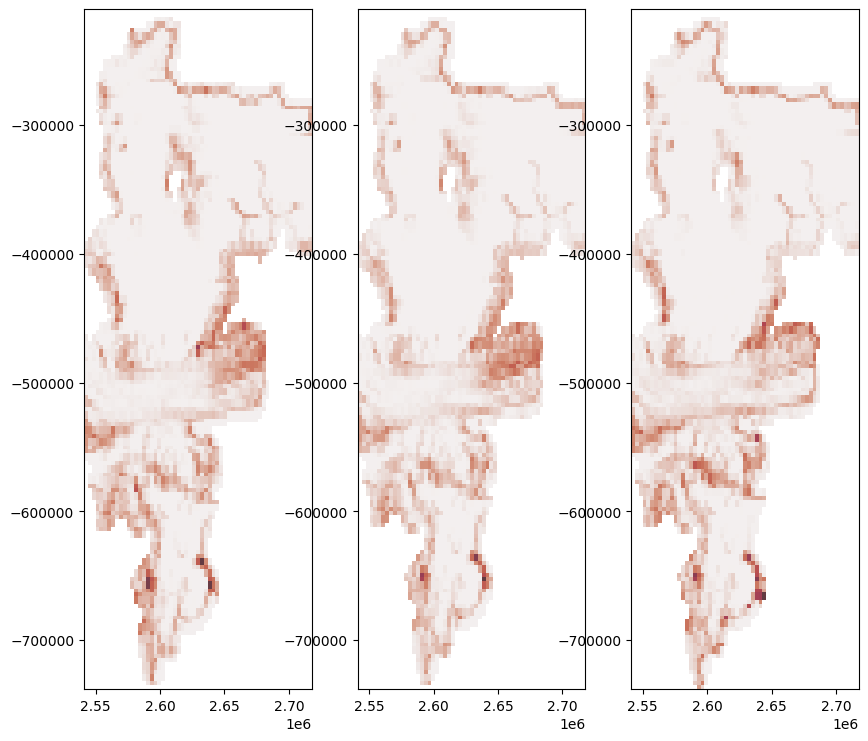

In [4]:
dmg_files = [
    "2018_S1_3000m_masked_dmg.tif",
    "2019_S1_3000m_masked_dmg.tif",
    "2020_S1_3000m_masked_dmg.tif",
]

dmg_outputs = []
dmg_transforms = []
fig, axes = plt.subplots(1, 3, figsize = (10, 20))
for i, f in enumerate(dmg_files):
    raster, transform, meta = app.geotiffs.open(
        os.path.join(data_dmg_folder, f)
    )
    if meta["nodata"] is not None:
        raster[raster == meta["nodata"]] = np.nan  # Convert back to NaN
    dmg_outputs.append(raster)
    dmg_transforms.append(transform)
    # print(raster, transform, meta)
    print(transform)
    # print(np.nanmedian(raster), raster[0, 0, 0])
    ax = axes.ravel()[i]
    rplt.show(raster, ax=ax, transform=transform, cmap="cmo.amp", alpha=0.8)

(1, 176, 59)
| 3000.00, 0.00, 2540895.00|
| 0.00,-3000.00,-210075.00|
| 0.00, 0.00, 1.00|
(1, 176, 59)
| 3000.00, 0.00, 2540895.00|
| 0.00,-3000.00,-210075.00|
| 0.00, 0.00, 1.00|
(1, 176, 59)
| 3000.00, 0.00, 2540895.00|
| 0.00,-3000.00,-210075.00|
| 0.00, 0.00, 1.00|


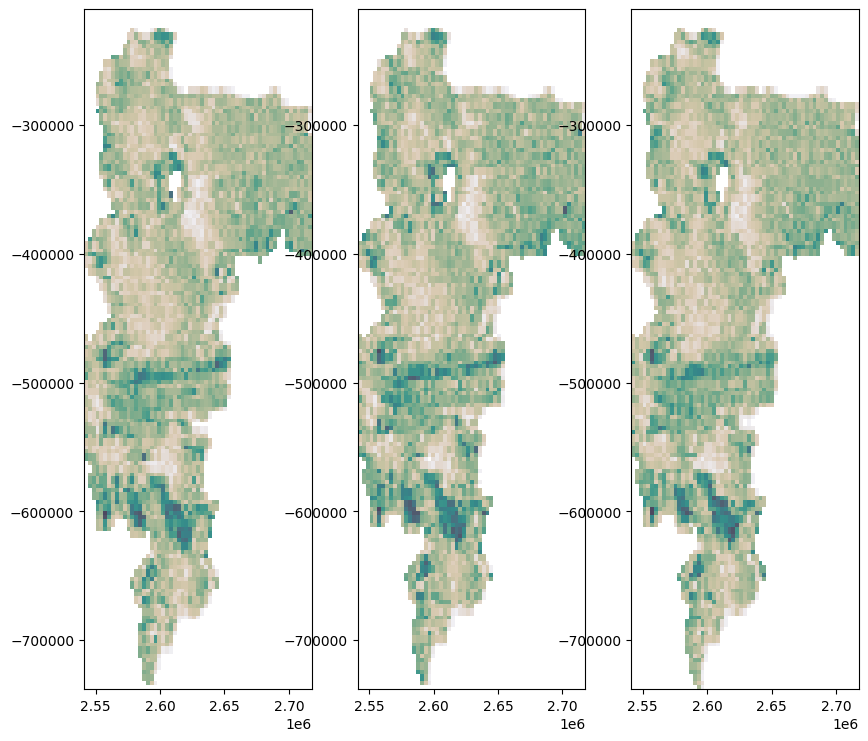

In [5]:
act_files = [
    "2018_S1_3000m_masked_activeness.tif",
    "2019_S1_3000m_masked_activeness.tif",
    "2020_S1_3000m_masked_activeness.tif",
]

act_outputs = []
act_transforms = []
fig, axes = plt.subplots(1, 3, figsize = (10, 20))
for i, f in enumerate(act_files):
    raster, transform, meta = app.geotiffs.open(
        os.path.join(data_dmg_folder, f)
    )
    if meta["nodata"] is not None:
        raster[raster == meta["nodata"]] = np.nan  # Convert back to NaN
    act_outputs.append(raster)
    act_transforms.append(transform)
    # print(raster, transform, meta)
    print(raster.shape)
    print(transform)
    ax = axes.ravel()[i]
    rplt.show(raster, ax=ax, transform=transform, cmap="cmo.rain", alpha=0.8)

(1, 176, 59) (176, 59) 2556275.6779863248 -254610.4015923628 14 5


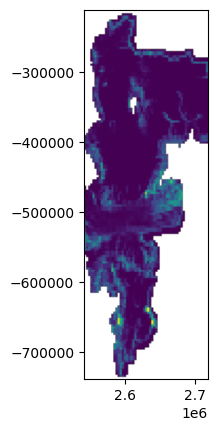

0.007414844798918185
(1, 176, 59) (176, 59) 2556275.6779863248 -254610.4015923628 14 5


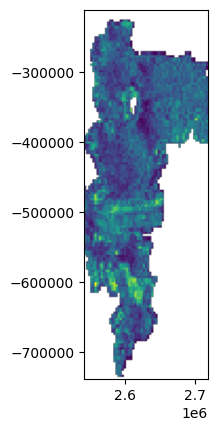

0.20618015718732788
(1, 176, 59) (176, 59) 2557205.8070161366 -256922.90475509234 15 5


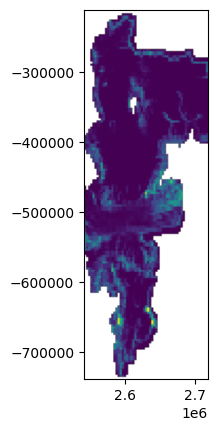

0.0
(1, 176, 59) (176, 59) 2557205.8070161366 -256922.90475509234 15 5


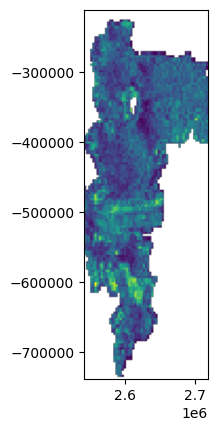

0.1360063924435611
(1, 176, 59) (176, 59) 2558699.398955425 -258069.24206707446 15 5


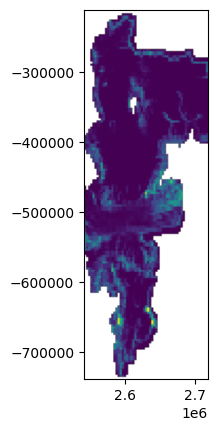

0.0
(1, 176, 59) (176, 59) 2558699.398955425 -258069.24206707446 15 5


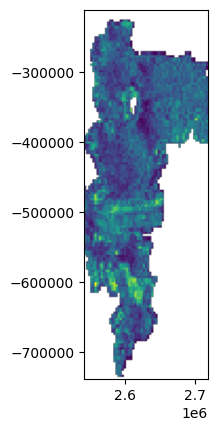

0.1360063924435611
(1, 176, 59) (176, 59) 2553811.141338789 -349000.0308269329 46 4


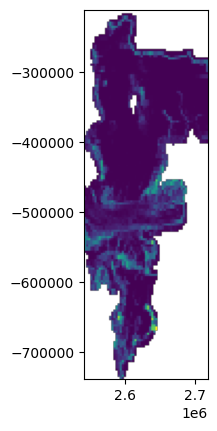

nan
(1, 176, 59) (176, 59) 2553811.141338789 -349000.0308269329 46 4


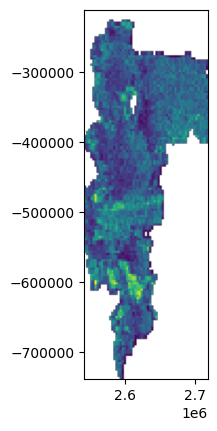

nan
(1, 176, 59) (176, 59) 2563306.901904274 -364995.27205240267 51 7


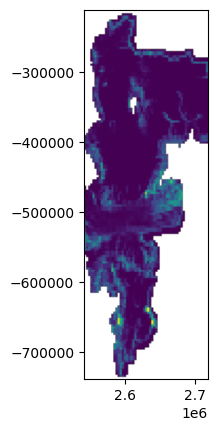

0.011056022815321124
(1, 176, 59) (176, 59) 2563306.901904274 -364995.27205240267 51 7


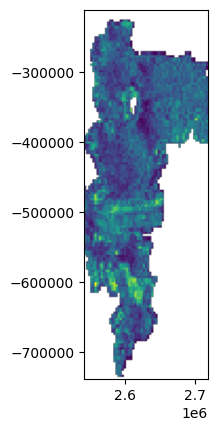

0.37214516571456285
(1, 176, 59) (176, 59) 2640302.3454630864 -394293.2858908731 61 33


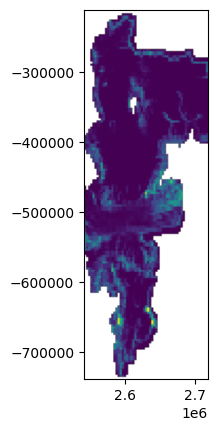

0.0
(1, 176, 59) (176, 59) 2640302.3454630864 -394293.2858908731 61 33


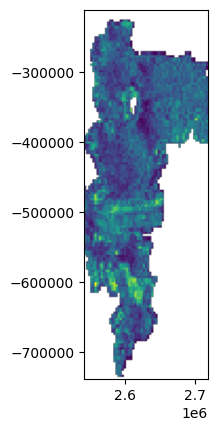

0.2592875287719637
(1, 176, 59) (176, 59) 2573243.364437825 -401593.8463649743 63 10


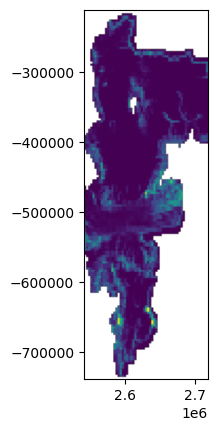

0.0
(1, 176, 59) (176, 59) 2573243.364437825 -401593.8463649743 63 10


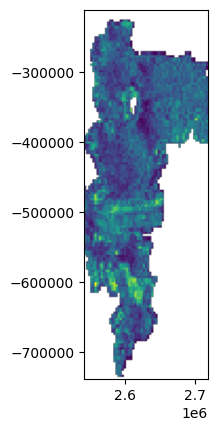

0.10950637455425884
(1, 176, 59) (176, 59) 2577450.447094967 -441465.44837652595 77 12


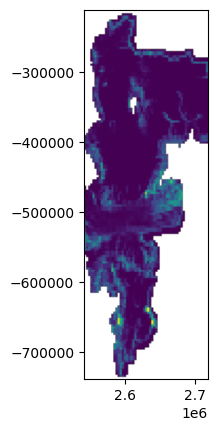

0.00011156410994780285
(1, 176, 59) (176, 59) 2577450.447094967 -441465.44837652595 77 12


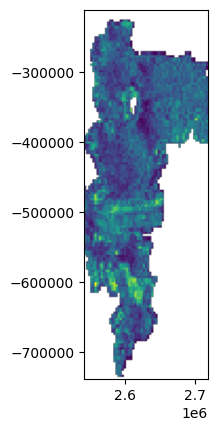

0.2048324965115888
(1, 176, 59) (176, 59) 2557013.7021868755 -440962.2579265467 76 5


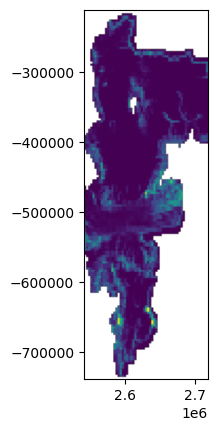

nan
(1, 176, 59) (176, 59) 2557013.7021868755 -440962.2579265467 76 5


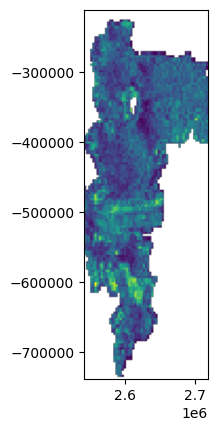

nan
(1, 176, 59) (176, 59) 2556055.9070111983 -444050.4516597597 77 5


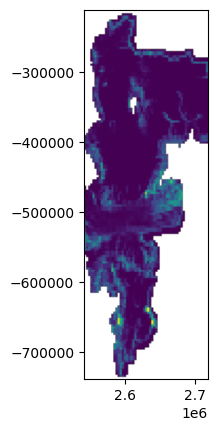

nan
(1, 176, 59) (176, 59) 2556055.9070111983 -444050.4516597597 77 5


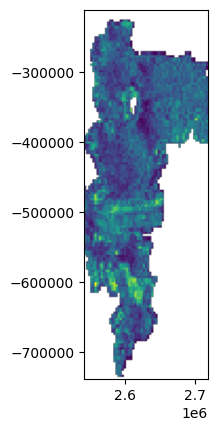

nan
(1, 176, 59) (176, 59) 2558789.240784917 -471302.44251963653 87 5


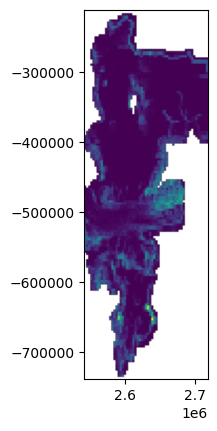

0.00708266343543581
(1, 176, 59) (176, 59) 2558789.240784917 -471302.44251963653 87 5


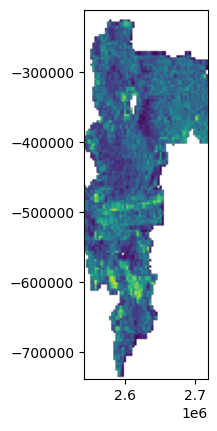

0.46373452859981046
(1, 176, 59) (176, 59) 2583759.6404527077 -477793.2111927403 89 14


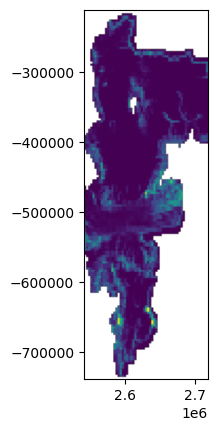

0.016681961365825282
(1, 176, 59) (176, 59) 2583759.6404527077 -477793.2111927403 89 14


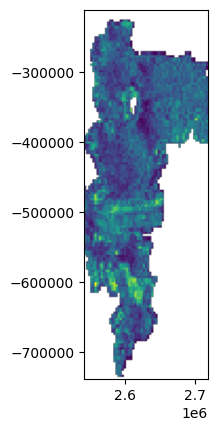

0.18852938019535578
(1, 176, 59) (176, 59) 2576277.3637739494 -480348.5183478707 90 11


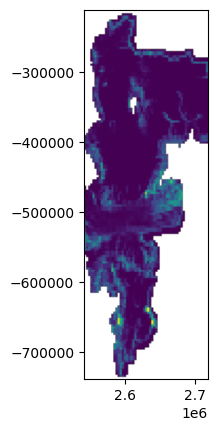

0.051431662005242705
(1, 176, 59) (176, 59) 2576277.3637739494 -480348.5183478707 90 11


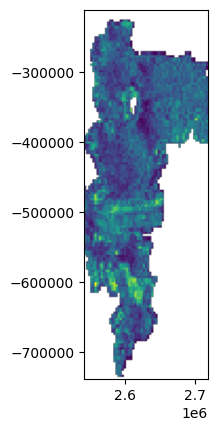

0.3480780927619953


In [6]:
dmg_values = []
dmg_percentile = []
active_values = []
active_percentile = []

for i, row in enumerate(events.iterrows()):
    row = row[1]
    i_summer = row["summer"] - 2019
    dmg_values.append(
        app.geotiffs.get_value(
            raster = dmg_outputs[i_summer],
            transform = dmg_transforms[i_summer],
            x = row["geometry"].x,
            y = row["geometry"].y,
        )
    )
    dmg_percentile.append(
        dmg_outputs[i_summer][dmg_outputs[i_summer] < dmg_values[-1]].size
        / dmg_outputs[i_summer][~np.isnan(dmg_outputs[i_summer])].size
    )
    active_values.append(
        app.geotiffs.get_value(
            act_outputs[i_summer],
            act_transforms[i_summer],
            row["geometry"].x,
            row["geometry"].y,
        )
    )
    active_percentile.append(
        act_outputs[i_summer][act_outputs[i_summer] < active_values[-1]].size
        / act_outputs[i_summer][~np.isnan(act_outputs[i_summer])].size
    )
events["dmg"] = dmg_values
events["active"] = active_values

In [7]:
events["dmg"]

0     0.007415
1     0.000000
2     0.000000
3          NaN
4     0.011056
5     0.000000
6     0.000000
7     0.000112
8          NaN
9          NaN
10    0.007083
11    0.016682
12    0.051432
Name: dmg, dtype: float64

In [8]:
def get_buckets(arr):
    number_of_buckets = 8
    percentiles = np.linspace(0, 100, number_of_buckets + 1)  # Define percentile bin edges
    bin_edges = np.percentile(arr[(~np.isnan(arr))].ravel(), percentiles)  # Compute bin edges
    return list(bin_edges.data), percentiles

dmg_buckets, ps = get_buckets(dmg_outputs[1].copy())
act_buckets, _ = get_buckets(act_outputs[1].copy())
print(dmg_buckets)
print(act_buckets)
print(ps)

[0.0, 0.0, 0.00019593509459448876, 0.001882422030200797, 0.012335725182376018, 0.043776023179494264, 0.10441469476662285, 0.20494487005084056, 1.0]
[0.0015025721998662245, 0.16553124840829428, 0.22439260428870192, 0.2708593312280354, 0.3135282432638973, 0.3593566953598584, 0.4079897366678561, 0.48249121377273385, 1.0]
[  0.   12.5  25.   37.5  50.   62.5  75.   87.5 100. ]


In [9]:
limit0_dmg_id = 5
limit1_dmg_id = 7
limit0_act_id = 1
limit1_act_id = 6
limit0_dmg = dmg_buckets[limit0_dmg_id]
limit1_dmg = dmg_buckets[limit1_dmg_id]
limit0_act = act_buckets[limit0_act_id]
limit1_act = act_buckets[limit1_act_id]
dmg_res = []
act_res = []
for i in range(len(dmg_outputs)):
    act = act_outputs[i]
    dmg = dmg_outputs[i]

    dmg_res.append(
        np.array(
            [
                dmg[(~np.isnan(dmg)) & (dmg < limit0_dmg)].size
                / dmg[~np.isnan(dmg)].size,
                dmg[(~np.isnan(dmg)) & (dmg >= limit0_dmg) & (dmg < limit1_dmg)].size
                / dmg[~np.isnan(dmg)].size,
                dmg[(~np.isnan(dmg)) & (dmg > limit1_dmg)].size
                / dmg[~np.isnan(dmg)].size,
            ]
        )
    )
    act_res.append(
        np.array(
            [
                act[(~np.isnan(act)) & (act < limit0_act)].size
                / act[~np.isnan(act)].size,
                act[(~np.isnan(act)) & (act >= limit0_act) & (act < limit1_act)].size
                / act[~np.isnan(act)].size,
                act[(~np.isnan(act)) & (act > limit1_act)].size
                / act[~np.isnan(act)].size,
            ]
        )
    )

dmg_res = np.array(dmg_res).mean(axis = 0)
dmg_counts = np.array(
    [
        events[events["dmg"] < limit0_dmg]["dmg"].size,
        events[(events["dmg"] > limit0_dmg) & (events["dmg"] < limit1_dmg)]["dmg"].size,
        events[events["dmg"] > limit1_dmg]["dmg"].size,
    ]
)
act_res = np.array(act_res).mean(axis = 0)
act_counts = np.array(
    [
        events[events["active"] < limit0_act]["active"].size,
        events[(events["active"] > limit0_act) & (events["active"] < limit1_act)][
            "active"
        ].size,
        events[events["active"] > limit1_act]["active"].size,
    ]
)
print(dmg_res, dmg_counts, np.array([ps[limit0_dmg_id], ps[limit1_dmg_id] - ps[limit0_dmg_id], 100 - ps[limit1_dmg_id]]).tolist())
print(act_res, act_counts, np.array([ps[limit0_act_id], ps[limit1_act_id] - ps[limit0_act_id], 100 - ps[limit1_act_id]]).tolist())

[0.62203064 0.23970331 0.13826605] [9 1 0] [62.5, 25.0, 12.5]
[0.13461822 0.65236872 0.21301306] [3 6 1] [12.5, 62.5, 25.0]


In [10]:

events.to_excel(os.path.join(data_folder, "shackleton_hydrofractures_processed.xlsx"))